# Восстановление золота из руды

В данном проекте необходимо подготовить модель машинного обучения для предсказания коэффициента восстановления золота из золотосодержащей руды для компании "Золото". Модель поможет оптимизировать производство, чтобы не запускать предприятие с убыточными характеристиками. Использованы данные с параметрами добычи и очистки.

Предварительно необходимо провести анализ данных по следующему плану:
1. Изучить общую информацию об исходных данных.
2. Проверить, что эффективность обогащения рассчитана правильно.
3. Проанализировать признаки, отсутствующие в тестовой выборке.
4. Провести предобработку данных.
5. Посмотреть, как меняется концентрация металлов (Au, Ag, Pb) на различных этапах очистки.
6. Сравнить распределения размеров гранул сырья на обучающей и тестовой выборках.
7. Исследовать суммарную концентрацию всех веществ на разных стадиях: в сырье, в черновом и финальном концентратах.

Подготовку модели необходимо провести по следующему плану:
1. Написать функцию для вычисления sMAPE.
2. Обучить разные модели и оцените их качество; выбрать лучшую модель и проверьте её на тестовой выборке.

После подготовки модели необходимо сделать общий вывод.

## Подготовка данных

Импортируем необходимые библиотеки:

In [6]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

Получим данные из файлов:

In [8]:
train_data = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_train_new.csv', sep=',')
test_data = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_test_new.csv', sep=',')
full_data = pd.read_csv('https://code.s3.yandex.net/datasets/gold_recovery_full_new.csv', sep=',')

### Предобработка данных

Посмотрим на общую информацию о данных:

In [11]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14149 entries, 0 to 14148
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                14149 non-null  object 
 1   final.output.concentrate_ag                         14148 non-null  float64
 2   final.output.concentrate_pb                         14148 non-null  float64
 3   final.output.concentrate_sol                        13938 non-null  float64
 4   final.output.concentrate_au                         14149 non-null  float64
 5   final.output.recovery                               14149 non-null  float64
 6   final.output.tail_ag                                14149 non-null  float64
 7   final.output.tail_pb                                14049 non-null  float64
 8   final.output.tail_sol                               14144 non-null  float64


In [12]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5290 entries, 0 to 5289
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5290 non-null   object 
 1   primary_cleaner.input.sulfate               5286 non-null   float64
 2   primary_cleaner.input.depressant            5285 non-null   float64
 3   primary_cleaner.input.feed_size             5290 non-null   float64
 4   primary_cleaner.input.xanthate              5286 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5290 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5290 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5290 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5290 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5290 non-null   float64
 10  primary_clea

In [13]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19439 entries, 0 to 19438
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                19439 non-null  object 
 1   final.output.concentrate_ag                         19438 non-null  float64
 2   final.output.concentrate_pb                         19438 non-null  float64
 3   final.output.concentrate_sol                        19228 non-null  float64
 4   final.output.concentrate_au                         19439 non-null  float64
 5   final.output.recovery                               19439 non-null  float64
 6   final.output.tail_ag                                19438 non-null  float64
 7   final.output.tail_pb                                19338 non-null  float64
 8   final.output.tail_sol                               19433 non-null  float64


Типы данных в столбцах соответствуют содержимому.

В датасетах есть пропущенные значения, их можно заменить на медианные значения. Перед заменой пропущенных значений проверим, есть ли в датасетах выбивающиеся значения, а также дубликаты. Если такие значения есть, ряды с такими значениями необходимо удалить, т.к. их наличие может привести к ошибке при определении медианных значений. Оценим значения в датасетах:

In [16]:
train_data.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,14148.000000,14148.000000,13938.000000,14149.000000,14149.000000,14149.000000,14049.000000,14144.000000,14149.000000,14129.000000,...,14143.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14147.000000,14148.000000
mean,5.142034,10.132960,9.202849,44.003792,66.518832,9.607035,2.597298,10.512122,2.918421,133.320659,...,19.985454,-478.696836,15.487065,-460.229416,16.775136,-483.956022,13.064590,-483.966564,19.577539,-506.798480
std,1.369586,1.654930,2.790516,4.905261,10.295402,2.319069,0.971843,3.003617,0.903712,39.431659,...,5.657723,50.736021,5.255655,58.843586,5.831906,37.892788,5.765617,39.207913,5.764417,37.079249
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003112,...,0.000000,-799.709069,0.000000,-799.889113,-0.372054,-797.142475,0.646208,-800.006180,0.195324,-809.398668
25%,4.211620,9.297355,7.484645,43.276111,62.545817,7.997429,1.905973,8.811324,2.368607,107.006651,...,14.990775,-500.628656,11.894558,-500.149000,11.083980,-500.363177,8.994405,-500.105994,14.989304,-500.745104
50%,4.994652,10.297144,8.845462,44.872436,67.432775,9.480270,2.592022,10.514621,2.851025,133.018328,...,20.001789,-499.681450,14.975536,-499.388738,17.932223,-499.702452,11.997547,-499.914556,19.984175,-500.061431
75%,5.859540,11.170603,10.487508,46.166425,72.346428,11.003707,3.241723,11.933009,3.434764,159.825396,...,24.990826,-477.472413,20.059375,-400.039008,21.346550,-487.712108,17.982903,-453.186936,24.991623,-499.536466
max,16.001945,17.031899,18.124851,52.756638,100.000000,19.552149,5.639565,22.317730,8.197408,250.127834,...,30.115735,-245.239184,24.007913,-145.071088,43.709931,-275.073125,27.926001,-157.396071,32.188906,-104.427459


In [17]:
test_data.describe()

,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,5286.000000,5285.000000,5290.000000,5286.000000,5.290000e+03,5290.000000,5.290000e+03,5290.000000,5.290000e+03,5290.000000,...,5.290000e+03,5290.000000,5.290000e+03,5290.000000,5290.000000,5290.000000,5290.000000,5290.000000,5290.000000,5290.000000
mean,174.839652,8.683596,7.266339,1.383803,1.539494e+03,-497.665883,1.545174e+03,-500.273098,1.527272e+03,-498.330680,...,1.632007e+01,-505.144570,1.373544e+01,-463.349858,12.804186,-501.329122,9.881145,-495.663398,17.304935,-501.793193
std,43.027080,3.072050,0.610219,0.643474,1.167979e+02,19.952431,1.222246e+02,32.968307,1.225380e+02,21.964876,...,3.493583e+00,31.427337,3.430484e+00,86.189107,3.026591,17.951495,2.868205,34.535007,4.536544,39.044215
min,2.566156,0.003839,5.650000,0.004984,5.445860e-32,-795.316337,6.647490e-32,-799.997015,4.033736e-32,-799.960571,...,1.079872e-16,-799.798523,2.489718e-17,-800.836914,0.069227,-797.323986,0.528083,-800.220337,-0.079426,-809.741464
25%,147.121401,6.489555,6.890000,0.907623,1.498936e+03,-500.357298,1.498971e+03,-500.703002,1.473230e+03,-501.018117,...,1.403618e+01,-500.868258,1.202862e+01,-500.323028,10.914838,-500.726841,8.036719,-500.194668,13.997317,-500.690984
50%,177.828489,8.052207,7.250000,1.197610,1.585129e+03,-499.969164,1.595622e+03,-500.028514,1.549595e+03,-500.017711,...,1.700847e+01,-500.115727,1.496486e+01,-499.576513,12.954182,-499.990332,10.004301,-499.990535,16.014935,-500.007126
75%,208.125438,10.027764,7.600000,1.797819,1.602077e+03,-499.568951,1.602324e+03,-499.293257,1.601144e+03,-498.994130,...,1.803862e+01,-499.404224,1.596213e+01,-400.933805,15.097528,-499.283191,11.997467,-499.719913,21.020013,-499.373018
max,265.983123,40.000000,15.500000,4.102454,2.103104e+03,-57.195404,1.813084e+03,-142.527229,1.715054e+03,-150.937035,...,3.005180e+01,-401.565212,3.126971e+01,-6.506986,25.258848,-244.483566,14.086866,-137.740004,26.705889,-123.307487


In [18]:
full_data.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,19438.000000,19438.000000,19228.000000,19439.000000,19439.000000,19438.000000,19338.000000,19433.000000,19439.000000,19415.000000,...,19433.000000,19438.000000,19438.000000,19438.000000,19438.000000,19438.000000,19438.000000,19438.000000,19437.000000,19438.000000
mean,5.168470,9.978895,9.501224,44.076513,67.050208,9.688589,2.705795,10.583728,3.042467,144.624774,...,18.987674,-485.894516,15.010366,-461.078636,15.694452,-488.684065,12.198224,-487.149827,18.959024,-505.436305
std,1.372348,1.669240,2.787537,5.129784,10.125840,2.328642,0.949077,2.868782,0.922808,44.464071,...,5.411058,47.758570,4.890228,67.405524,5.510974,34.533396,5.333024,38.347312,5.550498,37.689057
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003112,...,0.000000,-799.798523,0.000000,-800.836914,-0.372054,-797.323986,0.528083,-800.220337,-0.079426,-809.741464
25%,4.251240,9.137262,7.722820,43.402215,63.299712,8.062878,2.040119,8.938947,2.461138,114.107029,...,14.975734,-500.704892,11.940294,-500.187742,10.988606,-500.458467,8.971105,-500.129462,14.983037,-500.728067
50%,5.066094,10.102433,9.218961,45.011244,68.172738,9.743623,2.748730,10.622456,2.984909,143.232103,...,18.017481,-499.837793,14.971014,-499.459786,15.000036,-499.802605,11.019433,-499.935317,19.960541,-500.048400
75%,5.895527,11.035769,10.947813,46.275313,72.686642,11.134294,3.333216,12.104271,3.571351,175.075656,...,23.012470,-498.249730,19.034162,-400.118106,18.026190,-498.384187,14.019088,-499.436708,24.003170,-499.495378
max,16.001945,17.031899,19.615720,52.756638,100.000000,19.552149,5.804178,22.317730,8.245022,265.983123,...,30.115735,-245.239184,31.269706,-6.506986,43.709931,-244.483566,27.926001,-137.740004,32.188906,-104.427459


 Рассматриваемые параметры технологического процесса по смыслу являются неотрицательными значениями. Бросается в глаза большое число отрицательных параметров, преобразуем их в положительные. Для этого напишем функцию (добавим в функцию логирование с помощью print для отслеживания выполнения, т.к. операция занимает много времени):

In [20]:
def transform_values_to_positive(data):
    for i in range(len(data)):
        if i == 0 or i == len(data) - 1 or (i + 1) % 1000 == 0:
            print('Номер обрабатываемого ряда: ' + str(i + 1) + ' из ' + str(len(data)))
        for column in data.columns:
            if isinstance(data.loc[i, column], (int, float)):
                value = data.loc[i, column]
                if value < 0:
                    data.loc[i, column] = abs(value)

In [21]:
transform_values_to_positive(train_data)
transform_values_to_positive(test_data)
transform_values_to_positive(full_data)

Номер обрабатываемого ряда: 1 из 14149
Номер обрабатываемого ряда: 1000 из 14149
Номер обрабатываемого ряда: 2000 из 14149
Номер обрабатываемого ряда: 3000 из 14149
Номер обрабатываемого ряда: 4000 из 14149
Номер обрабатываемого ряда: 5000 из 14149
Номер обрабатываемого ряда: 6000 из 14149
Номер обрабатываемого ряда: 7000 из 14149
Номер обрабатываемого ряда: 8000 из 14149
Номер обрабатываемого ряда: 9000 из 14149
Номер обрабатываемого ряда: 10000 из 14149
Номер обрабатываемого ряда: 11000 из 14149
Номер обрабатываемого ряда: 12000 из 14149
Номер обрабатываемого ряда: 13000 из 14149
Номер обрабатываемого ряда: 14000 из 14149
Номер обрабатываемого ряда: 14149 из 14149
Номер обрабатываемого ряда: 1 из 5290
Номер обрабатываемого ряда: 1000 из 5290
Номер обрабатываемого ряда: 2000 из 5290
Номер обрабатываемого ряда: 3000 из 5290
Номер обрабатываемого ряда: 4000 из 5290
Номер обрабатываемого ряда: 5000 из 5290
Номер обрабатываемого ряда: 5290 из 5290
Номер обрабатываемого ряда: 1 из 19439
Но

Снова оценим значения в датасетах:

In [23]:
train_data.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,14148.000000,14148.000000,13938.000000,14149.000000,14149.000000,14149.000000,14049.000000,14144.000000,14149.000000,14129.000000,...,14143.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14147.000000,14148.000000
mean,5.142034,10.132960,9.202849,44.003792,66.518832,9.607035,2.597298,10.512122,2.918421,133.320659,...,19.985454,478.696836,15.487065,460.229416,16.776373,483.956022,13.064590,483.966564,19.577539,506.798480
std,1.369586,1.654930,2.790516,4.905261,10.295402,2.319069,0.971843,3.003617,0.903712,39.431659,...,5.657723,50.736021,5.255655,58.843586,5.828346,37.892788,5.765617,39.207913,5.764417,37.079249
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003112,...,0.000000,245.239184,0.000000,145.071088,0.112612,275.073125,0.646208,157.396071,0.195324,104.427459
25%,4.211620,9.297355,7.484645,43.276111,62.545817,7.997429,1.905973,8.811324,2.368607,107.006651,...,14.990775,477.472413,11.894558,400.039008,11.083980,487.712108,8.994405,453.186936,14.989304,499.536466
50%,4.994652,10.297144,8.845462,44.872436,67.432775,9.480270,2.592022,10.514621,2.851025,133.018328,...,20.001789,499.681450,14.975536,499.388738,17.932223,499.702452,11.997547,499.914556,19.984175,500.061431
75%,5.859540,11.170603,10.487508,46.166425,72.346428,11.003707,3.241723,11.933009,3.434764,159.825396,...,24.990826,500.628656,20.059375,500.149000,21.346550,500.363177,17.982903,500.105994,24.991623,500.745104
max,16.001945,17.031899,18.124851,52.756638,100.000000,19.552149,5.639565,22.317730,8.197408,250.127834,...,30.115735,799.709069,24.007913,799.889113,43.709931,797.142475,27.926001,800.006180,32.188906,809.398668


In [24]:
test_data.describe()

,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,5286.000000,5285.000000,5290.000000,5286.000000,5.290000e+03,5290.000000,5.290000e+03,5290.000000,5.290000e+03,5290.000000,...,5.290000e+03,5290.000000,5.290000e+03,5290.000000,5290.000000,5290.000000,5290.000000,5290.000000,5290.000000,5290.000000
mean,174.839652,8.683596,7.266339,1.383803,1.539494e+03,497.665883,1.545174e+03,500.273098,1.527272e+03,498.330680,...,1.632007e+01,505.144570,1.373544e+01,463.349858,12.804186,501.329122,9.881145,495.663398,17.304965,501.793193
std,43.027080,3.072050,0.610219,0.643474,1.167979e+02,19.952431,1.222246e+02,32.968307,1.225380e+02,21.964876,...,3.493583e+00,31.427337,3.430484e+00,86.189107,3.026591,17.951495,2.868205,34.535007,4.536429,39.044215
min,2.566156,0.003839,5.650000,0.004984,5.445860e-32,57.195404,6.647490e-32,142.527229,4.033736e-32,150.937035,...,1.079872e-16,401.565212,2.489718e-17,6.506986,0.069227,244.483566,0.528083,137.740004,0.016815,123.307487
25%,147.121401,6.489555,6.890000,0.907623,1.498936e+03,499.568951,1.498971e+03,499.293257,1.473230e+03,498.994130,...,1.403618e+01,499.404224,1.202862e+01,400.933805,10.914838,499.283191,8.036719,499.719913,13.997317,499.373018
50%,177.828489,8.052207,7.250000,1.197610,1.585129e+03,499.969164,1.595622e+03,500.028514,1.549595e+03,500.017711,...,1.700847e+01,500.115727,1.496486e+01,499.576513,12.954182,499.990332,10.004301,499.990535,16.014935,500.007126
75%,208.125438,10.027764,7.600000,1.797819,1.602077e+03,500.357298,1.602324e+03,500.703002,1.601144e+03,501.018117,...,1.803862e+01,500.868258,1.596213e+01,500.323028,15.097528,500.726841,11.997467,500.194668,21.020013,500.690984
max,265.983123,40.000000,15.500000,4.102454,2.103104e+03,795.316337,1.813084e+03,799.997015,1.715054e+03,799.960571,...,3.005180e+01,799.798523,3.126971e+01,800.836914,25.258848,797.323986,14.086866,800.220337,26.705889,809.741464


In [25]:
full_data.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,19438.000000,19438.000000,19228.000000,19439.000000,19439.000000,19438.000000,19338.000000,19433.000000,19439.000000,19415.000000,...,19433.000000,19438.000000,19438.000000,19438.000000,19438.000000,19438.000000,19438.000000,19438.000000,19437.000000,19438.000000
mean,5.168470,9.978895,9.501224,44.076513,67.050208,9.688589,2.705795,10.583728,3.042467,144.624774,...,18.987674,485.894516,15.010366,461.078636,15.695353,488.684065,12.198224,487.149827,18.959032,505.436305
std,1.372348,1.669240,2.787537,5.129784,10.125840,2.328642,0.949077,2.868782,0.922808,44.464071,...,5.411058,47.758570,4.890228,67.405524,5.508409,34.533396,5.333024,38.347312,5.550470,37.689057
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003112,...,0.000000,245.239184,0.000000,6.506986,0.069227,244.483566,0.528083,137.740004,0.016815,104.427459
25%,4.251240,9.137262,7.722820,43.402215,63.299712,8.062878,2.040119,8.938947,2.461138,114.107029,...,14.975734,498.249730,11.940294,400.118106,10.988606,498.384187,8.971105,499.436708,14.983037,499.495378
50%,5.066094,10.102433,9.218961,45.011244,68.172738,9.743623,2.748730,10.622456,2.984909,143.232103,...,18.017481,499.837793,14.971014,499.459786,15.000036,499.802605,11.019433,499.935317,19.960541,500.048400
75%,5.895527,11.035769,10.947813,46.275313,72.686642,11.134294,3.333216,12.104271,3.571351,175.075656,...,23.012470,500.704892,19.034162,500.187742,18.026190,500.458467,14.019088,500.129462,24.003170,500.728067
max,16.001945,17.031899,19.615720,52.756638,100.000000,19.552149,5.804178,22.317730,8.245022,265.983123,...,30.115735,799.798523,31.269706,800.836914,43.709931,797.323986,27.926001,800.220337,32.188906,809.741464


Сейчас характеристики значений выглядят правдоподобно.

Проверим, есть ли в датасетах дубликаты:

In [28]:
print(train_data.duplicated().sum())
print(test_data.duplicated().sum())
print(full_data.duplicated().sum())

0
0
0


Полных дубликатов нет. Проверим, есть ли повторяющиеся значения в столбцах `date`:

In [30]:
train_data['date'].value_counts(dropna=False).sort_values(ascending=False)

date
2016-01-15 00:00:00    1
2016-01-15 12:00:00    1
2016-01-16 01:00:00    1
2016-01-15 02:00:00    1
2016-01-15 03:00:00    1
                      ..
2018-08-18 03:59:59    1
2018-08-18 04:59:59    1
2018-08-18 05:59:59    1
2018-08-18 06:59:59    1
2018-08-18 10:59:59    1
Name: count, Length: 14149, dtype: int64

In [31]:
test_data['date'].value_counts(dropna=False).sort_values(ascending=False)

date
2016-09-01 00:59:59    1
2016-09-01 04:59:59    1
2016-09-01 06:59:59    1
2016-09-01 07:59:59    1
2016-09-01 08:59:59    1
                      ..
2017-12-31 19:59:59    1
2017-12-31 20:59:59    1
2017-12-31 21:59:59    1
2017-12-31 22:59:59    1
2017-12-31 23:59:59    1
Name: count, Length: 5290, dtype: int64

In [32]:
full_data['date'].value_counts(dropna=False).sort_values(ascending=False)

date
2016-01-15 00:00:00    1
2016-01-15 17:00:00    1
2016-01-15 03:00:00    1
2016-01-15 04:00:00    1
2016-01-15 05:00:00    1
                      ..
2018-08-18 06:59:59    1
2018-08-18 07:59:59    1
2018-08-18 08:59:59    1
2018-08-18 09:59:59    1
2018-08-18 10:59:59    1
Name: count, Length: 19439, dtype: int64

Значения в столбцах `date` являются уникальными.

Сейчас можно заменить пропущенные значения на медианные. Для этого напишем функцию:

In [35]:
def fill_nan_values_with_median_values(data):
    nan_values_number = data.isna().sum()
    columns_with_nan_values = nan_values_number[nan_values_number > 0].index
    for column in columns_with_nan_values:
        data.loc[data[column].isna(), column] = data[column].median()

In [36]:
fill_nan_values_with_median_values(train_data)
fill_nan_values_with_median_values(test_data)
fill_nan_values_with_median_values(full_data)

Проверим, что во входных данных не осталось пропусков:

In [38]:
train_data.isna().sum().sort_values(ascending=False)

date                                          0
rougher.state.floatbank10_b_air               0
rougher.state.floatbank10_f_air               0
rougher.state.floatbank10_e_level             0
rougher.state.floatbank10_e_air               0
                                             ..
primary_cleaner.state.floatbank8_c_level      0
primary_cleaner.state.floatbank8_c_air        0
primary_cleaner.state.floatbank8_b_level      0
primary_cleaner.state.floatbank8_b_air        0
secondary_cleaner.state.floatbank6_a_level    0
Length: 87, dtype: int64

In [39]:
test_data.isna().sum().sort_values(ascending=False)

date                                          0
rougher.state.floatbank10_c_air               0
rougher.state.floatbank10_d_air               0
rougher.state.floatbank10_d_level             0
rougher.state.floatbank10_e_air               0
rougher.state.floatbank10_e_level             0
rougher.state.floatbank10_f_air               0
rougher.state.floatbank10_f_level             0
secondary_cleaner.state.floatbank2_a_air      0
secondary_cleaner.state.floatbank2_a_level    0
secondary_cleaner.state.floatbank2_b_air      0
secondary_cleaner.state.floatbank2_b_level    0
secondary_cleaner.state.floatbank3_a_air      0
secondary_cleaner.state.floatbank3_a_level    0
secondary_cleaner.state.floatbank3_b_air      0
secondary_cleaner.state.floatbank3_b_level    0
secondary_cleaner.state.floatbank4_a_air      0
secondary_cleaner.state.floatbank4_a_level    0
secondary_cleaner.state.floatbank4_b_air      0
secondary_cleaner.state.floatbank4_b_level    0
secondary_cleaner.state.floatbank5_a_air

In [40]:
full_data.isna().sum().sort_values(ascending=False)

date                                          0
rougher.state.floatbank10_b_air               0
rougher.state.floatbank10_f_air               0
rougher.state.floatbank10_e_level             0
rougher.state.floatbank10_e_air               0
                                             ..
primary_cleaner.state.floatbank8_c_level      0
primary_cleaner.state.floatbank8_c_air        0
primary_cleaner.state.floatbank8_b_level      0
primary_cleaner.state.floatbank8_b_air        0
secondary_cleaner.state.floatbank6_a_level    0
Length: 87, dtype: int64

Посмотрим на первые 10 строк датасетов:

In [42]:
train_data.head(10)

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,502.488007,12.099931,504.715942,9.925633,498.310211,8.079666,500.470978,14.151341,605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,505.503262,11.950531,501.331529,10.039245,500.169983,7.984757,500.582168,13.998353,599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,502.520901,11.912783,501.133383,10.070913,500.129135,8.013877,500.517572,14.028663,601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,500.857308,11.999550,501.193686,9.970366,499.201640,7.977324,500.255908,14.005551,599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,499.838632,11.953070,501.053894,9.925709,501.686727,7.894242,500.356035,13.996647,601.496691
5,2016-01-15 05:00:00,6.482968,10.049416,5.480257,41.633678,69.465816,10.182708,0.664118,16.999638,1.918586,...,13.938497,500.970168,11.883350,500.395298,10.054147,496.374715,7.965083,499.364752,14.017067,599.707915
6,2016-01-15 06:00:00,6.533849,10.058141,4.569100,41.995316,69.300835,10.304598,0.807342,16.723575,2.058913,...,14.046819,500.971133,12.091543,500.501426,10.003247,497.083180,8.010890,500.002423,14.029649,600.905470
7,2016-01-15 07:00:00,6.130823,9.935481,4.389813,42.452727,70.230976,10.443288,0.949346,16.689959,2.143437,...,13.974691,501.819696,12.101324,500.583446,9.873169,499.171928,7.993381,499.794518,13.984498,600.411070
8,2016-01-15 08:00:00,5.834140,10.071156,4.876389,43.404078,69.688595,10.420140,1.065453,17.201948,2.209881,...,13.964030,504.252450,12.060738,501.174549,10.033838,501.178133,7.881604,499.729434,13.967135,599.061188
9,2016-01-15 09:00:00,5.687063,9.980404,5.282514,43.235220,70.279619,10.487013,1.159805,17.483979,2.209593,...,13.989632,503.195299,12.052233,500.928547,9.962574,502.986357,7.979219,500.146835,13.981614,598.070855


In [43]:
test_data.head(10)

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,500.225577,1399.144926,499.919735,1400.102998,...,12.023554,497.795834,8.016656,501.289139,7.946562,432.317850,4.872511,500.037437,26.705889,499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,500.057435,1398.055362,499.778182,1396.151033,...,12.058140,498.695773,8.130979,499.634209,7.958270,525.839648,4.878850,500.162375,25.019940,499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,500.868360,1398.860436,499.764529,1398.075709,...,11.962366,498.767484,8.096893,500.827423,8.071056,500.801673,4.905125,499.828510,24.994862,500.622559
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,498.863574,1397.440120,499.211024,1400.129303,...,12.033091,498.350935,8.074946,499.474407,7.897085,500.868509,4.931400,499.963623,24.948919,498.709987
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,500.808305,1398.128818,499.504543,1402.172226,...,12.025367,500.786497,8.054678,500.397500,8.107890,509.526725,4.957674,500.360026,25.003331,500.856333
5,2016-09-01 05:59:59,168.485085,8.817007,7.420000,0.791191,1402.826803,499.299521,1401.511119,499.205357,1404.088107,...,12.029797,499.814895,8.036586,500.371492,8.041446,510.037054,4.983949,499.990990,24.978973,500.475640
6,2016-09-01 06:59:59,144.133440,7.924610,7.420000,0.788838,1398.252401,499.748672,1393.255503,499.195380,1396.738566,...,12.026296,499.473127,8.027984,500.983079,7.907340,507.964971,5.010224,500.043697,25.040709,499.501984
7,2016-09-01 07:59:59,133.513396,8.055252,6.988000,0.801871,1401.669677,501.777839,1400.754446,502.514024,1400.465244,...,12.040911,501.293852,8.020490,499.185229,8.116897,511.927561,5.036498,500.149615,25.032580,503.970657
8,2016-09-01 08:59:59,133.735356,7.999618,6.935000,0.789329,1402.358981,499.981597,1400.985954,496.802968,1401.168584,...,11.998184,499.481608,8.012610,500.896783,7.974422,521.199104,5.061599,499.791519,25.005063,497.613716
9,2016-09-01 09:59:59,126.961069,8.017856,7.030000,0.805298,1400.816120,499.014158,1399.975401,499.570552,1401.871924,...,12.040725,499.987743,7.989503,499.750625,7.989710,509.946737,5.068811,499.293900,24.992741,499.272255


In [44]:
full_data.head(10)

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,502.488007,12.099931,504.715942,9.925633,498.310211,8.079666,500.470978,14.151341,605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,505.503262,11.950531,501.331529,10.039245,500.169983,7.984757,500.582168,13.998353,599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,502.520901,11.912783,501.133383,10.070913,500.129135,8.013877,500.517572,14.028663,601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,500.857308,11.999550,501.193686,9.970366,499.201640,7.977324,500.255908,14.005551,599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,499.838632,11.953070,501.053894,9.925709,501.686727,7.894242,500.356035,13.996647,601.496691
5,2016-01-15 05:00:00,6.482968,10.049416,5.480257,41.633678,69.465816,10.182708,0.664118,16.999638,1.918586,...,13.938497,500.970168,11.883350,500.395298,10.054147,496.374715,7.965083,499.364752,14.017067,599.707915
6,2016-01-15 06:00:00,6.533849,10.058141,4.569100,41.995316,69.300835,10.304598,0.807342,16.723575,2.058913,...,14.046819,500.971133,12.091543,500.501426,10.003247,497.083180,8.010890,500.002423,14.029649,600.905470
7,2016-01-15 07:00:00,6.130823,9.935481,4.389813,42.452727,70.230976,10.443288,0.949346,16.689959,2.143437,...,13.974691,501.819696,12.101324,500.583446,9.873169,499.171928,7.993381,499.794518,13.984498,600.411070
8,2016-01-15 08:00:00,5.834140,10.071156,4.876389,43.404078,69.688595,10.420140,1.065453,17.201948,2.209881,...,13.964030,504.252450,12.060738,501.174549,10.033838,501.178133,7.881604,499.729434,13.967135,599.061188
9,2016-01-15 09:00:00,5.687063,9.980404,5.282514,43.235220,70.279619,10.487013,1.159805,17.483979,2.209593,...,13.989632,503.195299,12.052233,500.928547,9.962574,502.986357,7.979219,500.146835,13.981614,598.070855


Данные готовы для дальнейшего анализа.

### Проверка расчёта эффективности обогащения

Проверим, что эффективность обогащения рассчитана правильно. Вычислим её на обучающей выборке для признака rougher.output.recovery:

In [48]:
C = train_data['rougher.output.concentrate_au']
F = train_data['rougher.input.feed_au']
T = train_data['rougher.output.tail_au']

rougher_calculation_recovery = C * (F - T) / (F * (C - T)) * 100

Найдём MAE между расчётом и значением признака:

In [50]:
mean_absolute_error(train_data['rougher.output.recovery'], rougher_calculation_recovery)

9.73512347450521e-15

Крайне малое значение MAE говорит о том, что эффективность обогащения рассчитана правильно.

### Признаки, отсутствующие в тестовой выборке

Найдём признаки, отсутствующие в тестовой выборке, но присутствующие в обучающей выборке:

In [54]:
missing_test_data_columns = []

for column in train_data.columns:
    if column not in test_data.columns:
        missing_test_data_columns.append(column)

missing_test_data_columns

['final.output.concentrate_ag',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.concentrate_au',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'final.output.tail_au',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'primary_cleaner.output.tail_au',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.au_pb_ratio',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.concentrate_au',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_pb',
 'rougher.output.ta

Данные параметры выражены дробными числами.

## Анализ данных

### Изменение концентрации металлов (Au, Ag, Pb) на различных этапах очистки

Посмотрим, как изменяются во времени значения интересующих нас параметров.

Изменения во времени параметров группы rougher.input.feed:

<Axes: xlabel='Номер измерения', ylabel='rougher.input.feed_au'>

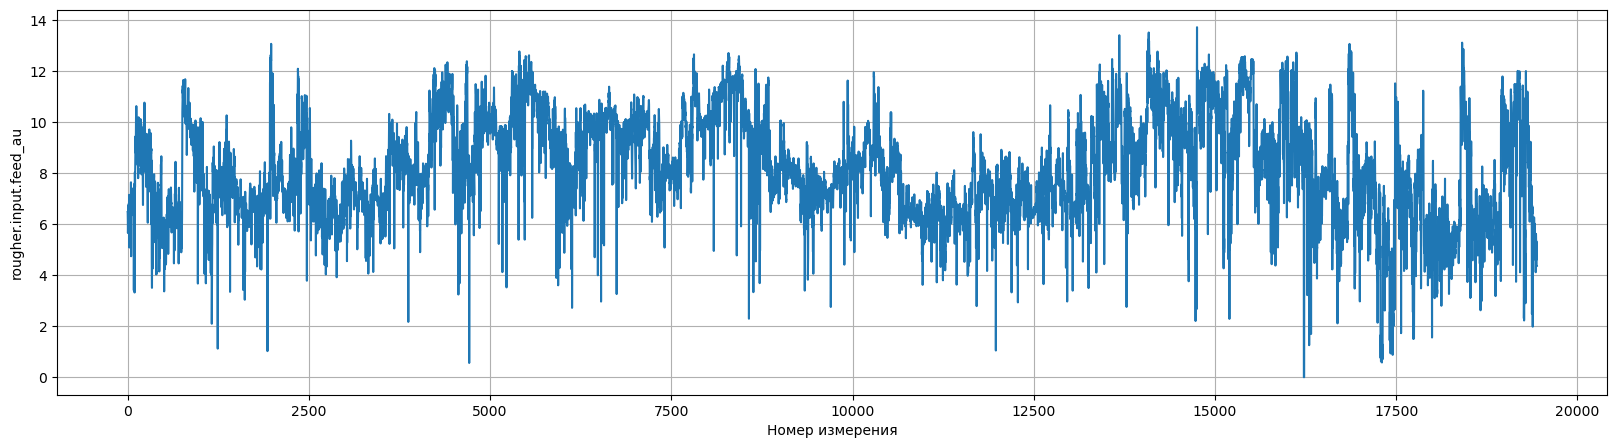

In [60]:
full_data['rougher.input.feed_au'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='rougher.input.feed_au')

<Axes: xlabel='Номер измерения', ylabel='rougher.input.feed_ag'>

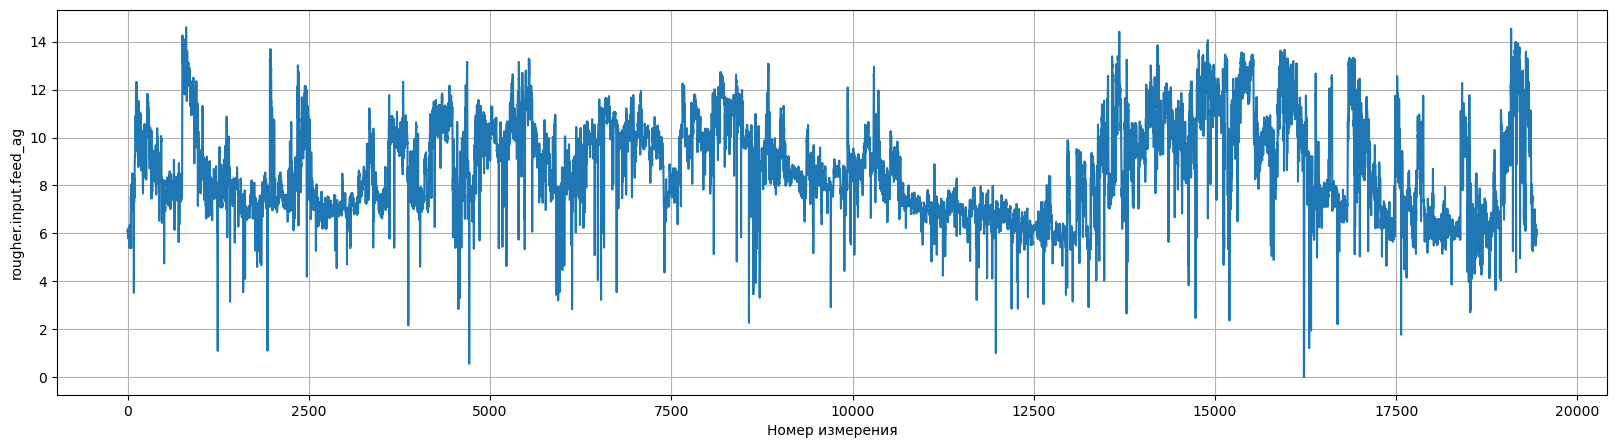

In [61]:
full_data['rougher.input.feed_ag'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='rougher.input.feed_ag')

<Axes: xlabel='Номер измерения', ylabel='rougher.input.feed_pb'>

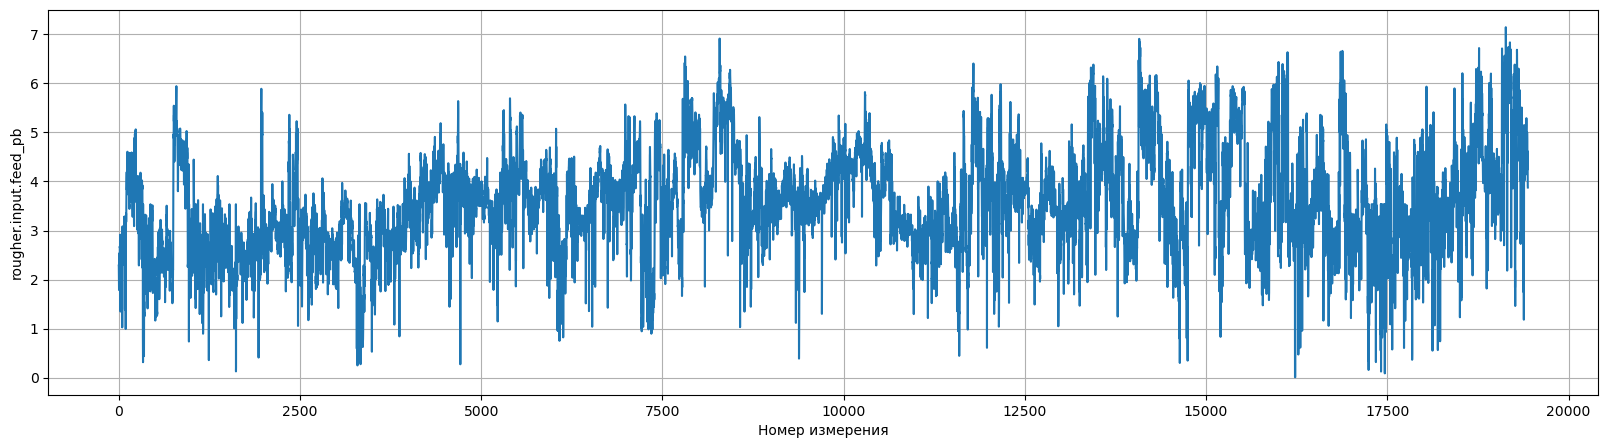

In [62]:
full_data['rougher.input.feed_pb'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='rougher.input.feed_pb')

Изменения во времени параметров группы rougher.output.concentrate:

<Axes: xlabel='Номер измерения', ylabel='rougher.output.concentrate_au'>

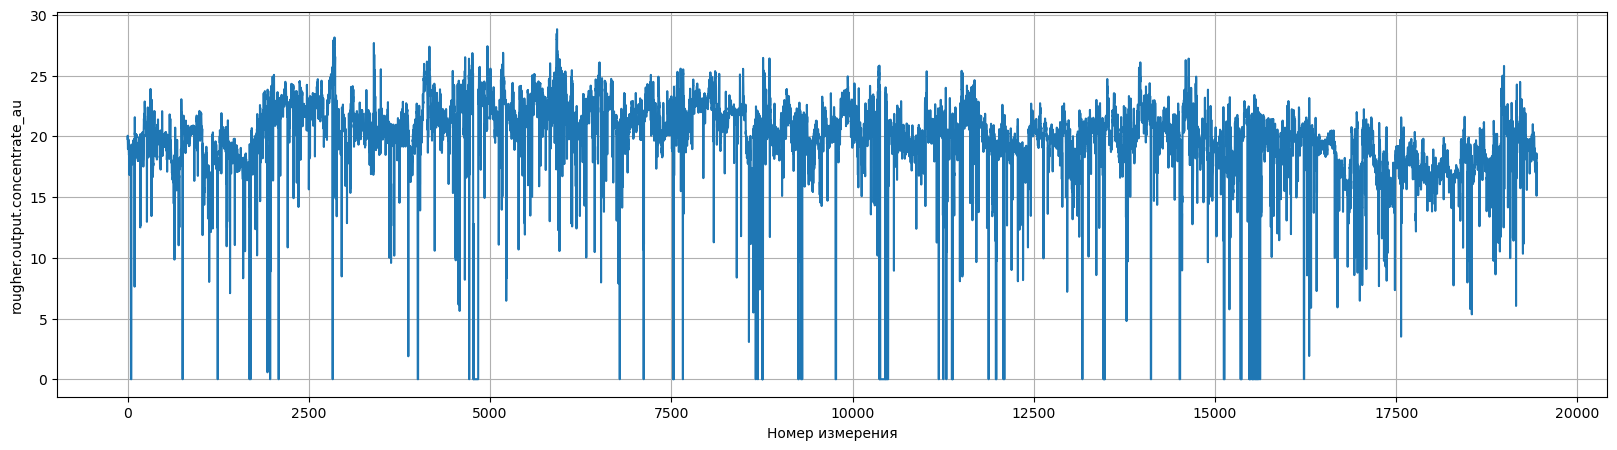

In [64]:
full_data['rougher.output.concentrate_au'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='rougher.output.concentrate_au')

<Axes: xlabel='Номер измерения', ylabel='rougher.output.concentrate_ag'>

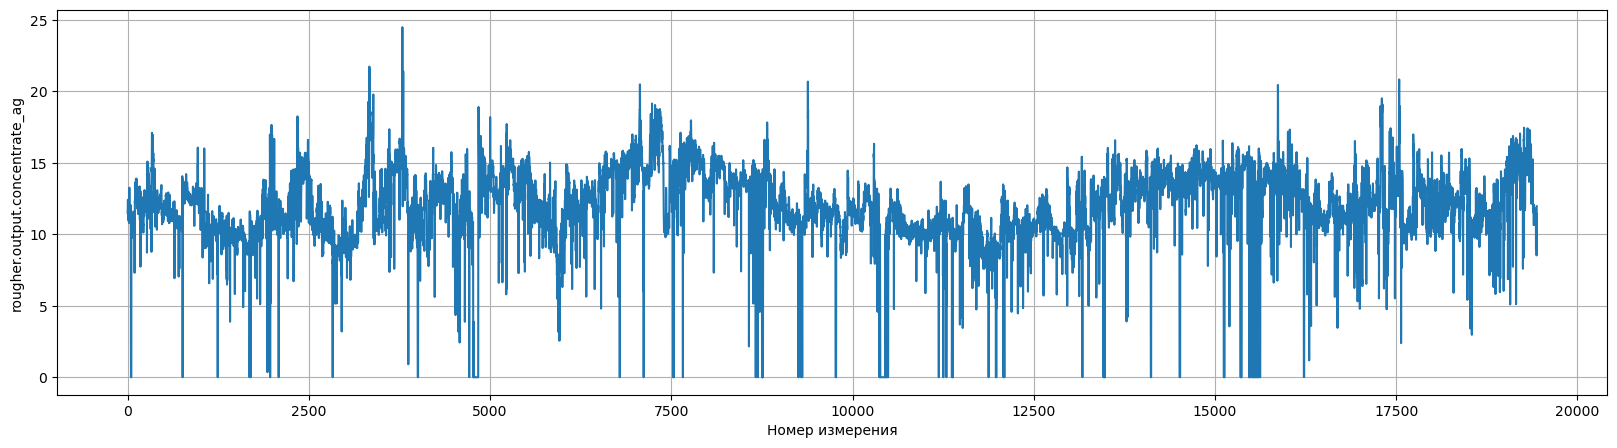

In [65]:
full_data['rougher.output.concentrate_ag'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='rougher.output.concentrate_ag')

<Axes: xlabel='Номер измерения', ylabel='rougher.output.concentrate_pb'>

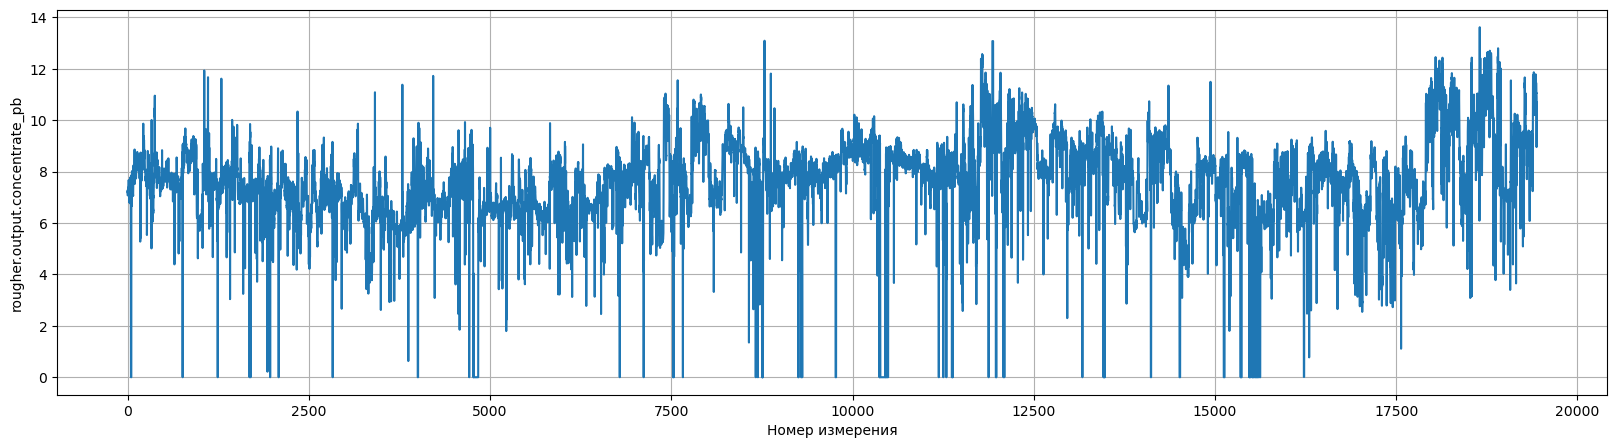

In [66]:
full_data['rougher.output.concentrate_pb'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='rougher.output.concentrate_pb')

Изменения во времени параметров группы primary_cleaner.output.concentrate:

<Axes: xlabel='Номер измерения', ylabel='primary_cleaner.output.concentrate_au'>

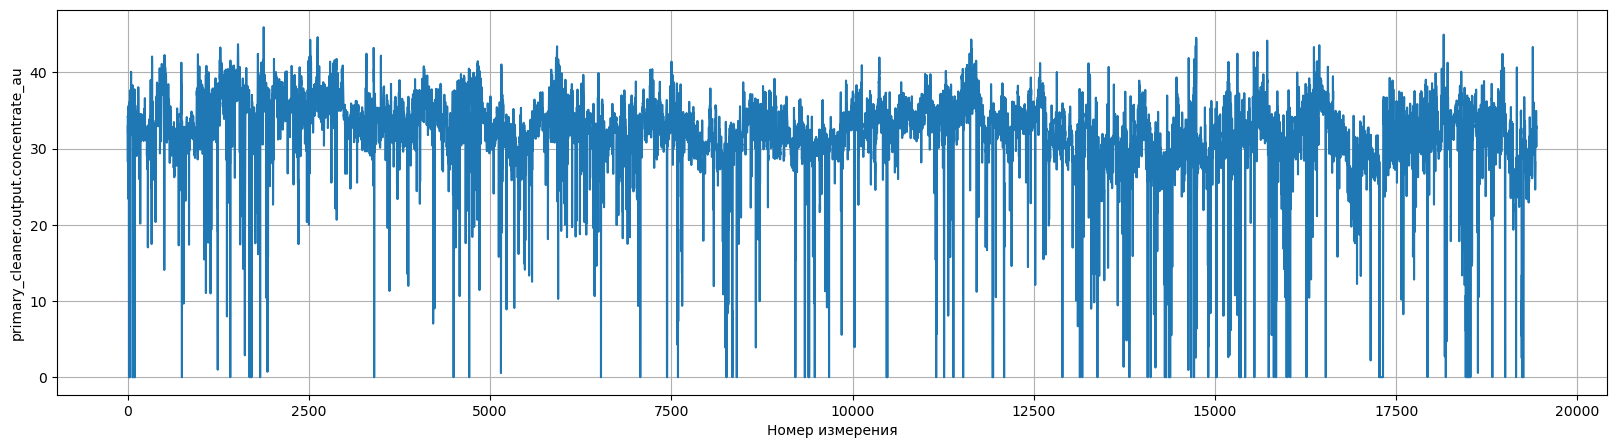

In [68]:
full_data['primary_cleaner.output.concentrate_au'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='primary_cleaner.output.concentrate_au')

<Axes: xlabel='Номер измерения', ylabel='primary_cleaner.output.concentrate_ag'>

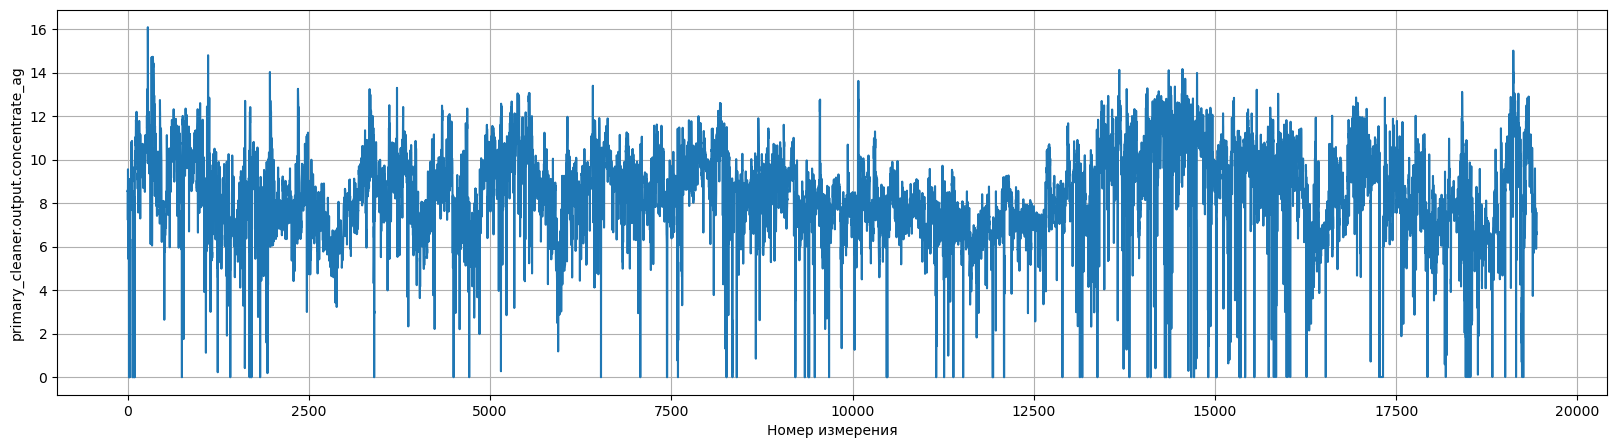

In [69]:
full_data['primary_cleaner.output.concentrate_ag'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='primary_cleaner.output.concentrate_ag')

<Axes: xlabel='Номер измерения', ylabel='primary_cleaner.output.concentrate_pb'>

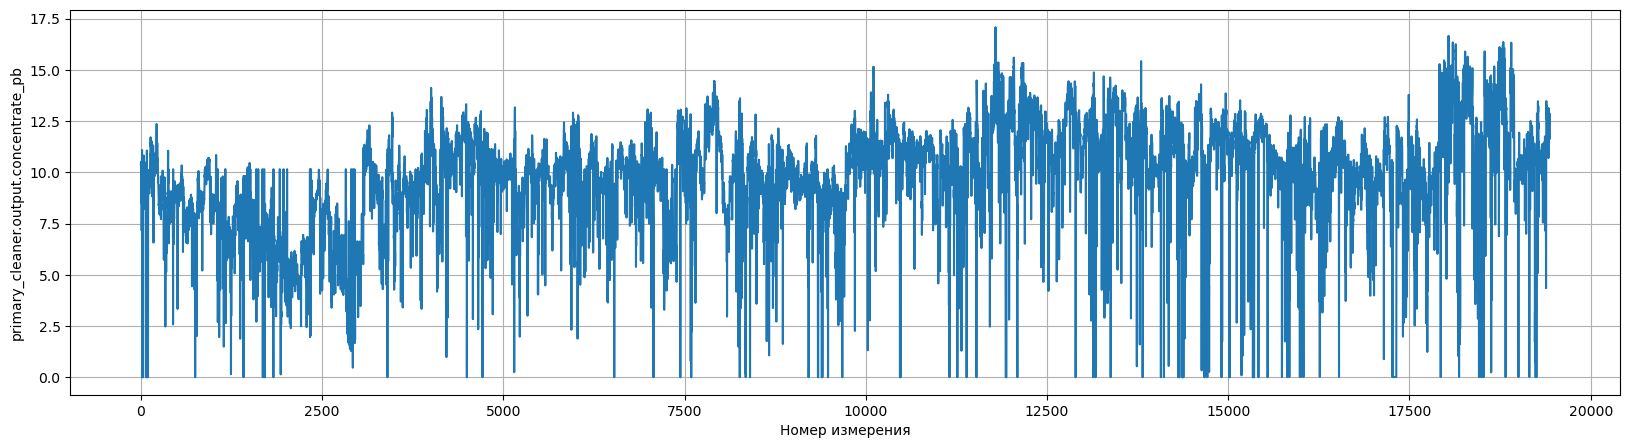

In [70]:
full_data['primary_cleaner.output.concentrate_pb'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='primary_cleaner.output.concentrate_pb')

Изменения во времени параметров группы final.output.concentrate:

<Axes: xlabel='Номер измерения', ylabel='final.output.concentrate_au'>

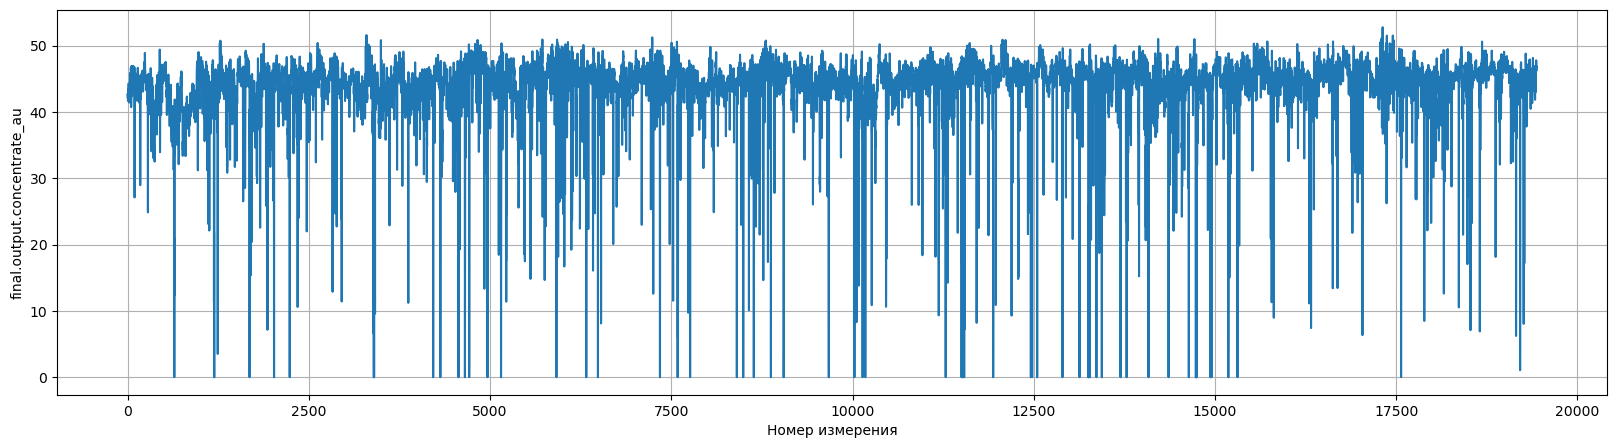

In [72]:
full_data['final.output.concentrate_au'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='final.output.concentrate_au')

<Axes: xlabel='Номер измерения', ylabel='final.output.concentrate_ag'>

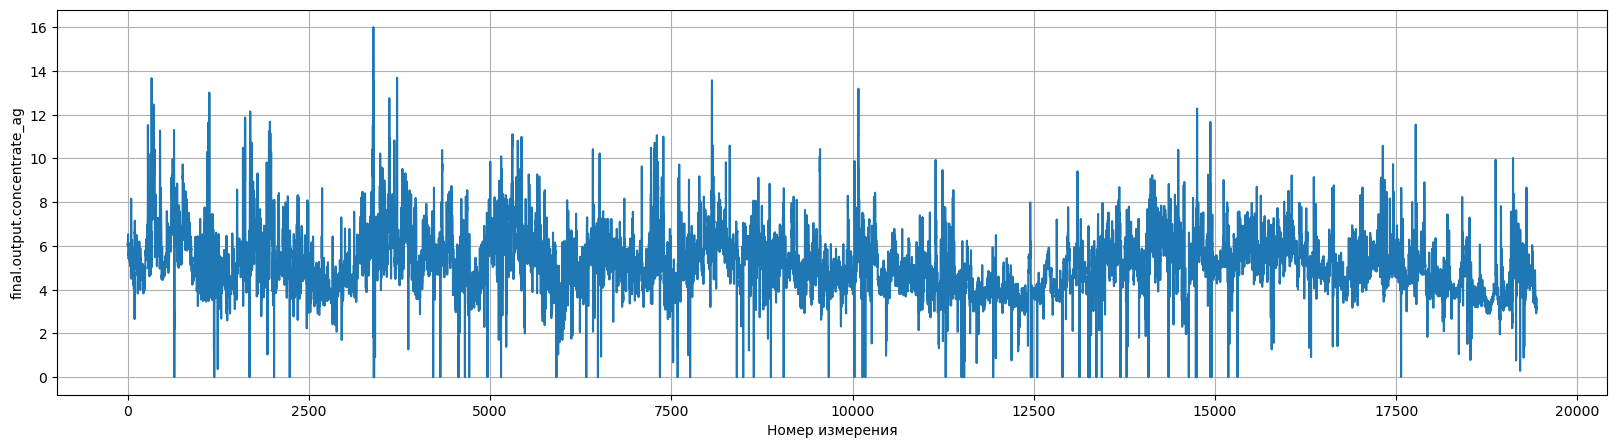

In [73]:
full_data['final.output.concentrate_ag'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='final.output.concentrate_ag')

<Axes: xlabel='Номер измерения', ylabel='final.output.concentrate_pb'>

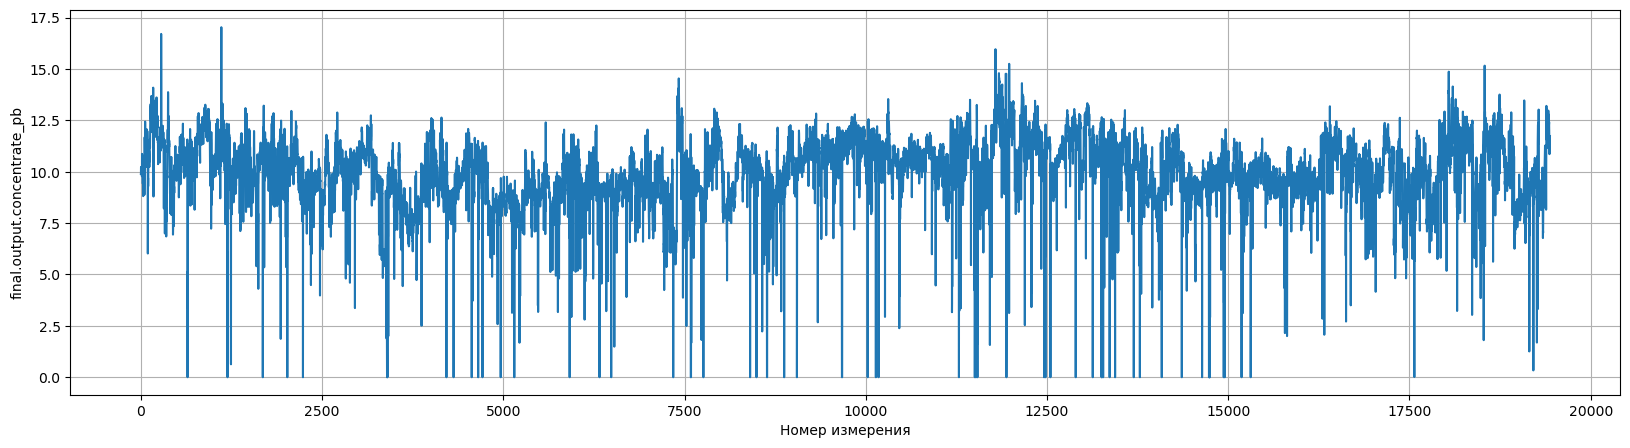

In [74]:
full_data['final.output.concentrate_pb'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='final.output.concentrate_pb')

Для оценки того, как меняется концентрация металлов на различных этапах очистки, используем медианные значения:

<Axes: >

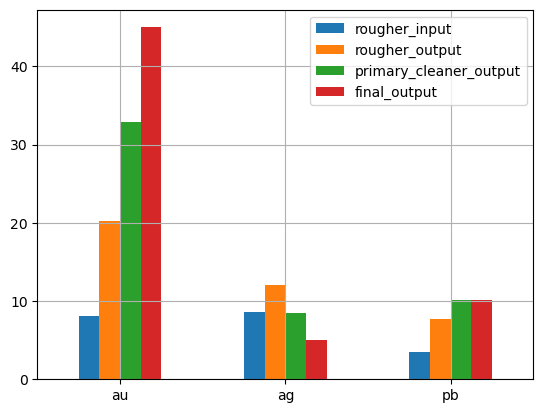

In [76]:
rougher_input_feed_au_median = full_data['rougher.input.feed_au'].median()
rougher_input_feed_ag_median = full_data['rougher.input.feed_ag'].median()
rougher_input_feed_pb_median = full_data['rougher.input.feed_pb'].median()

rougher_output_concentrate_au_median = full_data['rougher.output.concentrate_au'].median()
rougher_output_concentrate_ag_median = full_data['rougher.output.concentrate_ag'].median()
rougher_output_concentrate_pb_median = full_data['rougher.output.concentrate_pb'].median()

primary_cleaner_output_concentrate_au_median = full_data['primary_cleaner.output.concentrate_au'].median()
primary_cleaner_output_concentrate_ag_median = full_data['primary_cleaner.output.concentrate_ag'].median()
primary_cleaner_output_concentrate_pb_median = full_data['primary_cleaner.output.concentrate_pb'].median()

final_output_concentrate_au_median = full_data['final.output.concentrate_au'].median()
final_output_concentrate_ag_median = full_data['final.output.concentrate_ag'].median()
final_output_concentrate_pb_median = full_data['final.output.concentrate_pb'].median()

rougher_input_feed_median = [rougher_input_feed_au_median, rougher_input_feed_ag_median, rougher_input_feed_pb_median]
rougher_output_concentrate_median = [rougher_output_concentrate_au_median, rougher_output_concentrate_ag_median, rougher_output_concentrate_pb_median]
primary_cleaner_output_concentrate_median = [primary_cleaner_output_concentrate_au_median, primary_cleaner_output_concentrate_ag_median, primary_cleaner_output_concentrate_pb_median]
final_output_concentrate_median = [final_output_concentrate_au_median, final_output_concentrate_ag_median, final_output_concentrate_pb_median]
index = ['au', 'ag', 'pb']
df = pd.DataFrame({'rougher_input': rougher_input_feed_median,
                   'rougher_output': rougher_output_concentrate_median,
                   'primary_cleaner_output': primary_cleaner_output_concentrate_median,
                   'final_output': final_output_concentrate_median}, index=index)
df.plot.bar(rot=0, grid=True)

Концентрация золота ближе к концу технологического процесса растёт, а концентрация серебра уменьшается, что естественно. Наблюдается незначительное увеличение концентрации свинца, что может быть связано с особенностями технологического процесса.

### Сравнение распределения размеров гранул сырья на обучающей и тестовой выборках

Построим гистрограмму распределения значений параметра `rougher.input.feed_size` обучающей выборки:

<Axes: >

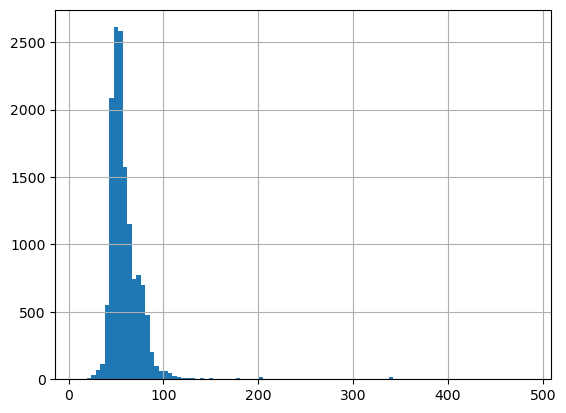

In [80]:
column = 'rougher.input.feed_size'
train_data[column].hist(bins=100)

Выделим интересующий нас диапазон:

<Axes: >

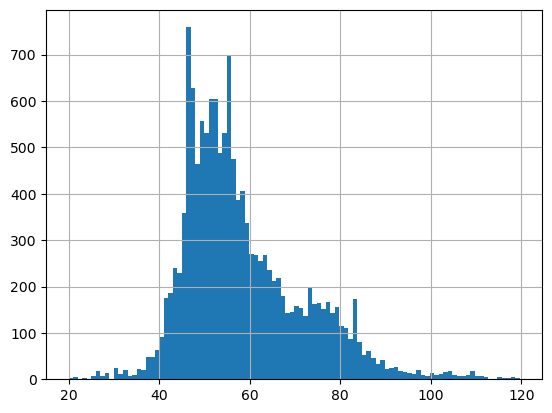

In [82]:
rougher_input_feed_size_train_sample = train_data[(train_data[column] > 20) & (train_data[column] < 120)][column]
rougher_input_feed_size_train_sample.hist(bins=100)

Построим гистрограмму распределения значений параметра rougher.input.feed_size тестовой выборки:

<Axes: >

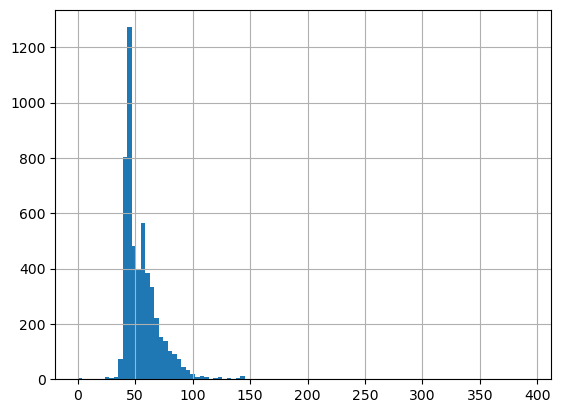

In [84]:
column = 'rougher.input.feed_size'
test_data[column].hist(bins=100)

Выделим интересующий нас диапазон:

<Axes: >

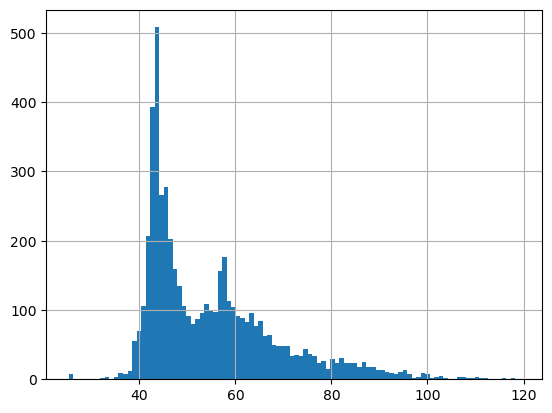

In [86]:
rougher_input_feed_size_test_sample = test_data[(test_data[column] > 20) & (test_data[column] < 120)][column]
rougher_input_feed_size_test_sample.hist(bins=100)

Построим нормализованные гистограммы на одном графике:

<Axes: ylabel='Density'>

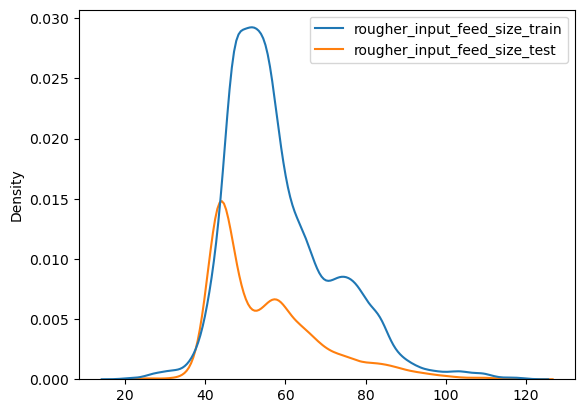

In [88]:
samples = pd.DataFrame({'rougher_input_feed_size_train': rougher_input_feed_size_train_sample,
                        'rougher_input_feed_size_test': rougher_input_feed_size_test_sample})

sns.kdeplot(data=samples)

Распределения параметра `rougher.input.feed_size` обучающей и тестовой выборок близки друг к другу.

Построим гистрограмму распределения значений параметра `primary_cleaner.input.feed_size` обучающей выборки:

<Axes: >

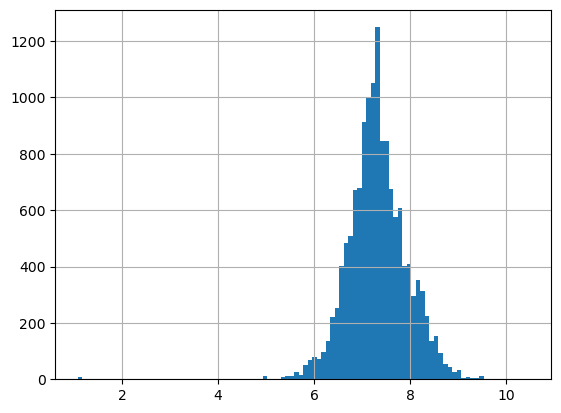

In [91]:
column = 'primary_cleaner.input.feed_size'
train_data[column].hist(bins=100)

Выделим интересующий нас диапазон:

<Axes: >

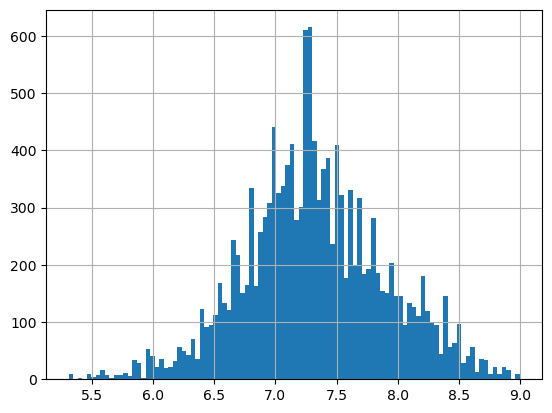

In [93]:
primary_cleaner_input_feed_size_train_sample = train_data[(train_data[column] > 5) & (train_data[column] < 9)][column]
primary_cleaner_input_feed_size_train_sample.hist(bins=100)

Построим гистрограмму распределения значений параметра primary_cleaner.input.feed_size тестовой выборки:

<Axes: >

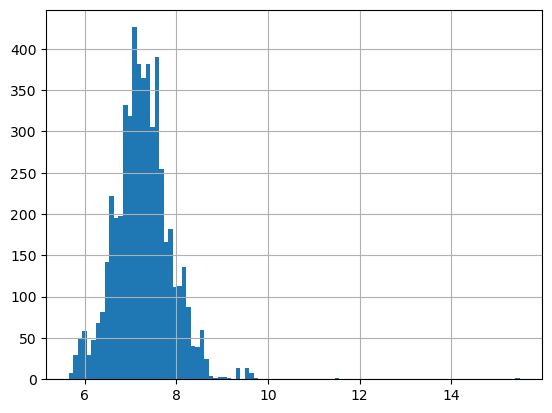

In [95]:
column = 'primary_cleaner.input.feed_size'
test_data[column].hist(bins=100)

Выделим интересующий нас диапазон:

<Axes: >

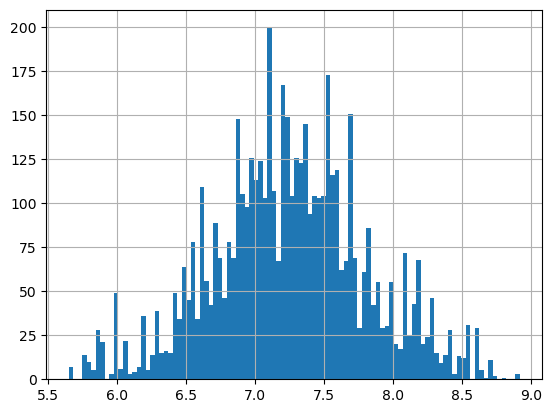

In [97]:
primary_cleaner_input_feed_size_test_sample = test_data[(test_data[column] > 5) & (test_data[column] < 9)][column]
primary_cleaner_input_feed_size_test_sample.hist(bins=100)

Построим нормализованные гистограммы на одном графике:

<Axes: ylabel='Density'>

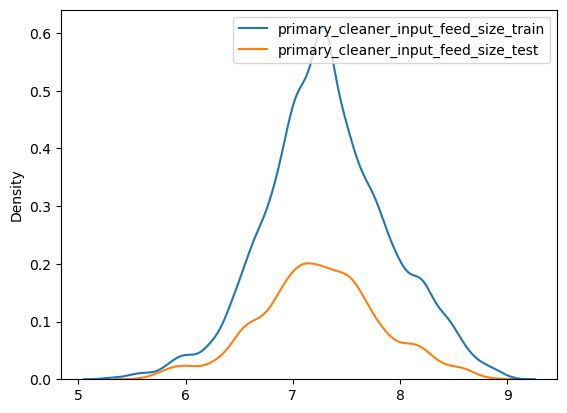

In [99]:
samples = pd.DataFrame({'primary_cleaner_input_feed_size_train': primary_cleaner_input_feed_size_train_sample,
                        'primary_cleaner_input_feed_size_test': primary_cleaner_input_feed_size_test_sample})

sns.kdeplot(data=samples)

Распределения параметра `primary_cleaner.input.feed_size` обучающей и тестовой выборок близки друг к другу.

Таким образом распределения размеров гранул сырья на обучающей и тестовой выборках примерно одинаковы.

### Изменение суммарной концентрации всех веществ на разных стадиях

Рассчитаем суммарную концентрацию всех веществ на разных стадиях:

In [104]:
full_data['rougher.input.feed_sum'] = full_data['rougher.input.feed_au'] + full_data['rougher.input.feed_ag'] + full_data['rougher.input.feed_pb'] + full_data['rougher.input.feed_sol']
full_data['rougher.output.concentrate_sum'] = full_data['rougher.output.concentrate_au'] + full_data['rougher.output.concentrate_ag'] + full_data['rougher.output.concentrate_pb'] + full_data['rougher.output.concentrate_sol']
full_data['primary_cleaner.output.concentrate_sum'] = full_data['primary_cleaner.output.concentrate_au'] + full_data['primary_cleaner.output.concentrate_ag'] + full_data['primary_cleaner.output.concentrate_pb'] + full_data['primary_cleaner.output.concentrate_sol']
full_data['final.output.concentrate_sum'] = full_data['final.output.concentrate_au'] + full_data['final.output.concentrate_ag'] + full_data['final.output.concentrate_pb'] + full_data['final.output.concentrate_sol']

Посмотрим, как меняется суммарная концентрация во времени на разных стадиях:

<Axes: xlabel='Номер измерения', ylabel='rougher.input.feed_sum'>

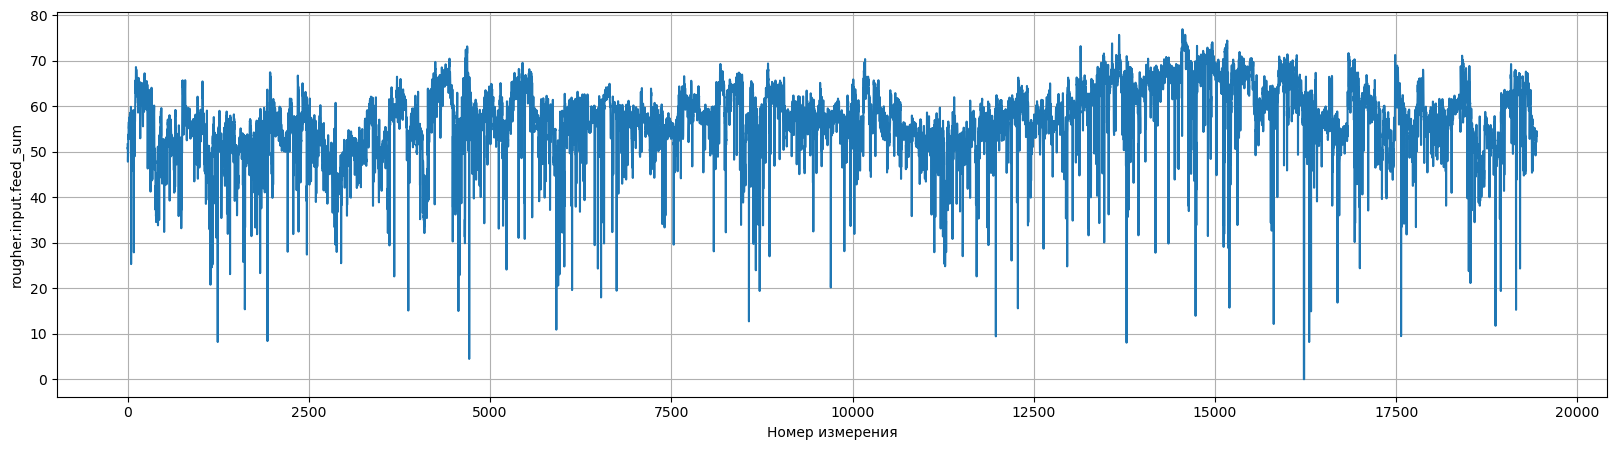

In [106]:
full_data['rougher.input.feed_sum'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='rougher.input.feed_sum')

<Axes: xlabel='Номер измерения', ylabel='rougher.output.concentrate_sum'>

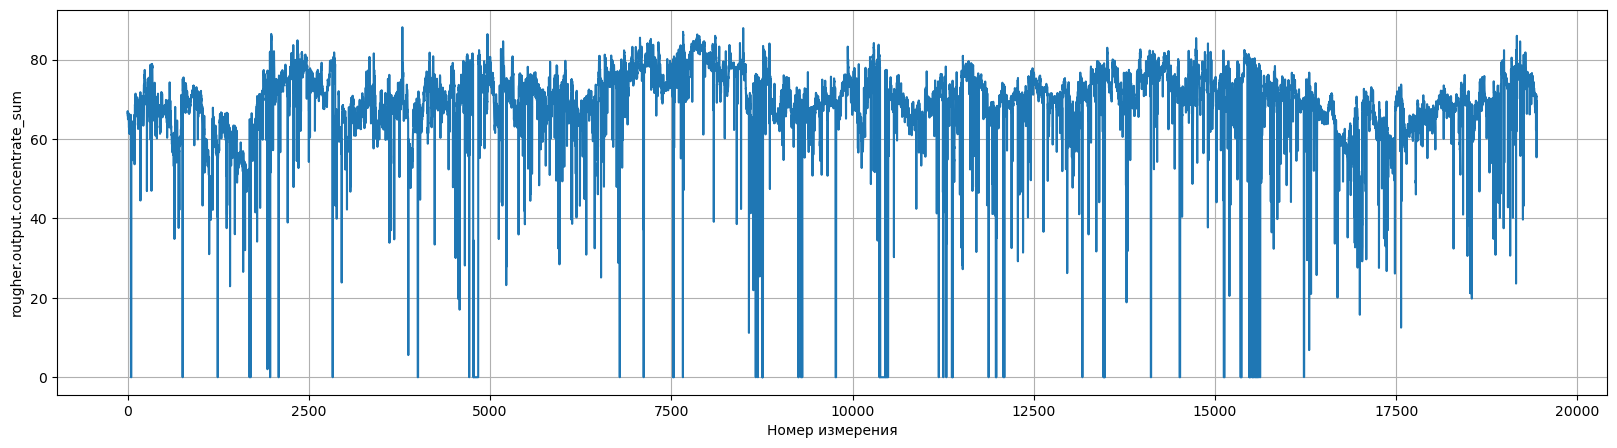

In [107]:
full_data['rougher.output.concentrate_sum'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='rougher.output.concentrate_sum')

<Axes: xlabel='Номер измерения', ylabel='primary_cleaner.output.concentrate_sum'>

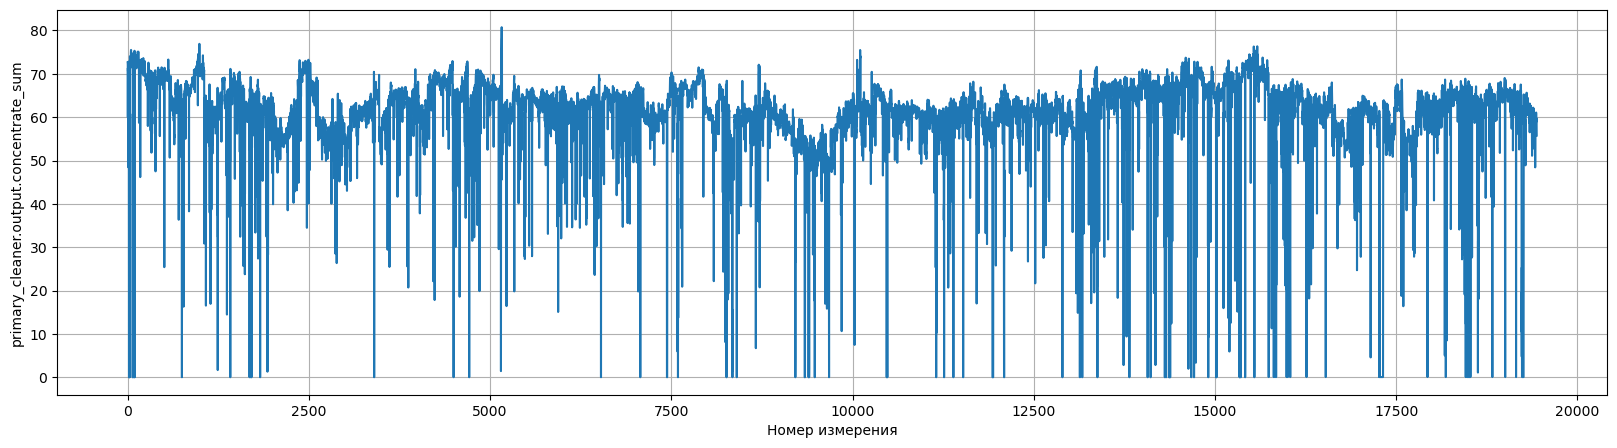

In [108]:
full_data['primary_cleaner.output.concentrate_sum'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='primary_cleaner.output.concentrate_sum')

<Axes: xlabel='Номер измерения', ylabel='final.output.concentrate_sum'>

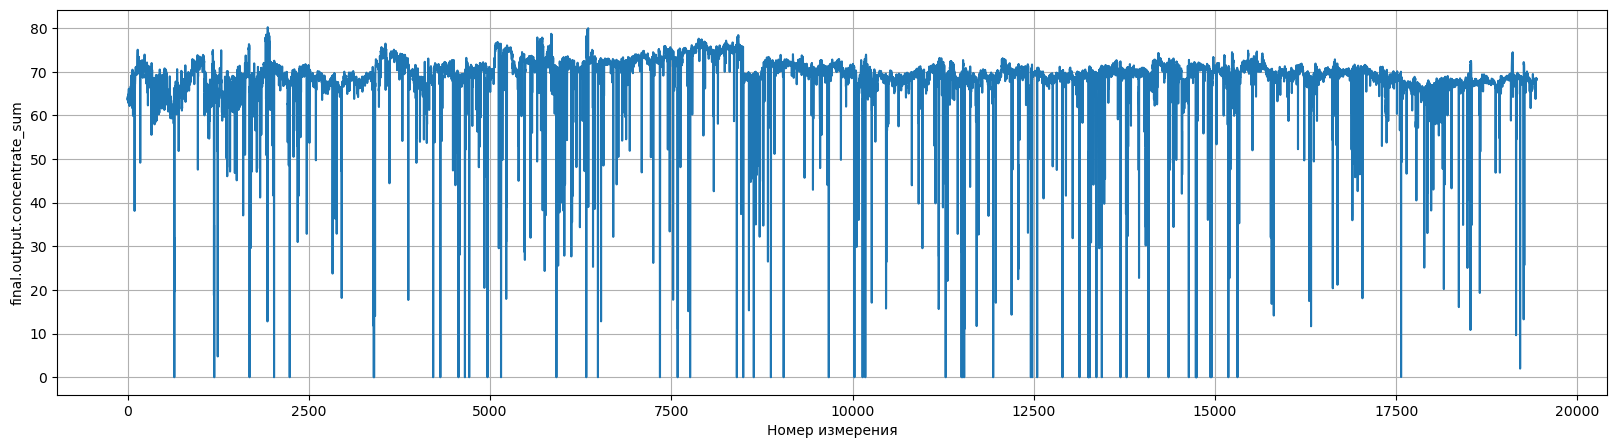

In [109]:
full_data['final.output.concentrate_sum'].plot(figsize=(20, 5), grid=True, xlabel='Номер измерения', ylabel='final.output.concentrate_sum')

<Axes: xlabel='rougher.input.feed_sum', ylabel='Count'>

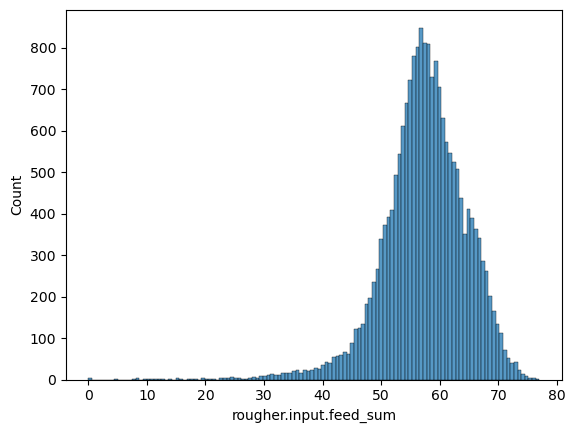

In [110]:
sns.histplot(data=full_data['rougher.input.feed_sum'])

<Axes: xlabel='rougher.output.concentrate_sum', ylabel='Count'>

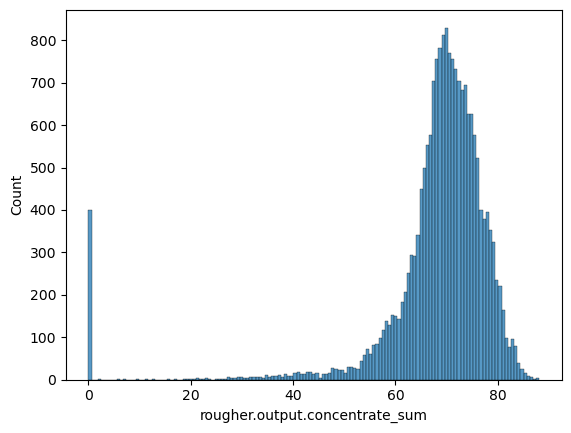

In [111]:
sns.histplot(data=full_data['rougher.output.concentrate_sum'])

<Axes: xlabel='primary_cleaner.output.concentrate_sum', ylabel='Count'>

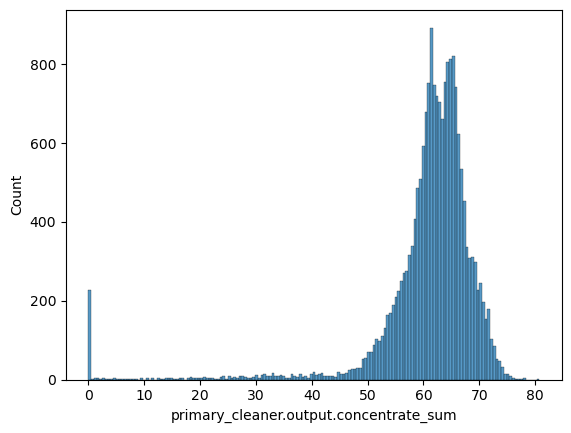

In [112]:
sns.histplot(data=full_data['primary_cleaner.output.concentrate_sum'])

<Axes: xlabel='final.output.concentrate_sum', ylabel='Count'>

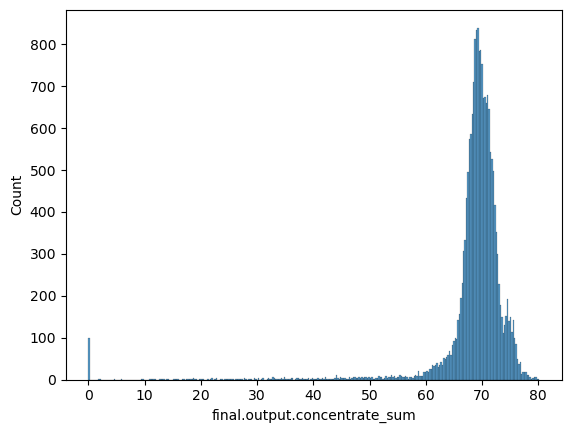

In [113]:
sns.histplot(data=full_data['final.output.concentrate_sum'])

На некоторых графиках видны пики, соответствующие нулевым значениям.

Удалим нулевые значения по приведенным выше рекомендациям:

In [116]:
for col in ['rougher.input.feed_sum', 'rougher.output.concentrate_sum', 'primary_cleaner.output.concentrate_sum', 'final.output.concentrate_sum']:
    full_data = full_data[full_data[col]>0]

Для оценки суммарной концентрации используем медианные значения:

<Axes: >

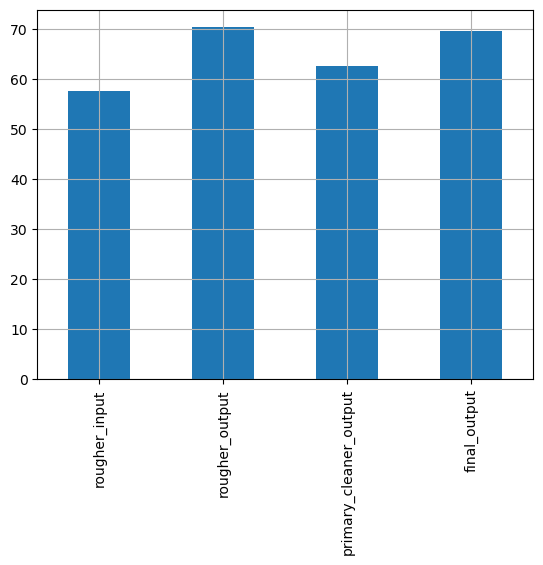

In [118]:
rougher_input_feed_sum_median = full_data['rougher.input.feed_sum'].median()
rougher_output_concentrate_sum_median = full_data['rougher.output.concentrate_sum'].median()
primary_cleaner_output_concentrate_sum_median = full_data['primary_cleaner.output.concentrate_sum'].median()
final_output_concentrate_sum_median = full_data['final.output.concentrate_sum'].median()

data = [rougher_input_feed_sum_median, rougher_output_concentrate_sum_median, primary_cleaner_output_concentrate_sum_median, final_output_concentrate_sum_median]
index = ['rougher_input', 'rougher_output', 'primary_cleaner_output', 'final_output']

pd.Series(data=data, index=index).plot.bar(grid=True)

Суммарная концентрация всех веществ незначительно возрастает от этапа rougher_input к этапу final_output.

После фильтрации full_data очистим train_data, преобразовав столбец с датой в индекс и взяв данные из full_data:

In [121]:
train_data = train_data.set_index('date')
full_data = full_data.set_index('date')
train_data = train_data.loc[train_data.index.isin(full_data.index)]

Преобразуем индекс в test_data аналогичным образом, чтобы датасеты имели однотипную структуру:

In [123]:
test_data = test_data.set_index('date')

## Модель

### Функция для вычисления итоговой sMAPE

Напишем функцию для вычисления sMAPE:

In [127]:
def calculate_smape(target, prediction):
    sum = 0
    for i in range(len(target)):
        target_value = target.iloc[i]
        prediction_value = prediction.iloc[i]
        sum = sum + abs(target_value - prediction_value) / ((abs(target_value) + abs(prediction_value)) / 2)
    return sum / len(target) * 100

Напишем функцию для вычисления итоговой sMAPE:

In [129]:
def calculate_final_smape(target, prediction):
    rougher_output_recovery_target = target['rougher.output.recovery']
    final_output_recovery_target = target['final.output.recovery']
    rougher_output_recovery_prediction = pd.Series(prediction[:, 0])
    final_output_recovery_prediction = pd.Series(prediction[:, 1])
    
    rougher_output_recovery_smape = calculate_smape(rougher_output_recovery_target, rougher_output_recovery_prediction)
    final_output_recovery_smape = calculate_smape(final_output_recovery_target, final_output_recovery_prediction)
    
    return 0.25 * rougher_output_recovery_smape + 0.75 * final_output_recovery_smape

### Обучение моделей

Для обучения моделей необходимо дополнить test_data недостающими столбцами из full_data. Это можно сделать, взяв ряды из full_data на основе индекса:

In [132]:
test_data = full_data.loc[full_data.index.isin(test_data.index)]

Проверим, что в test_data не появились пропуски в значениях:

In [134]:
test_data.isna().sum().sort_values(ascending=False)

final.output.concentrate_ag                 0
secondary_cleaner.output.tail_au            0
secondary_cleaner.output.tail_pb            0
secondary_cleaner.output.tail_ag            0
rougher.state.floatbank10_f_level           0
                                           ..
primary_cleaner.state.floatbank8_d_level    0
primary_cleaner.state.floatbank8_d_air      0
primary_cleaner.state.floatbank8_c_level    0
primary_cleaner.state.floatbank8_c_air      0
final.output.concentrate_sum                0
Length: 90, dtype: int64

Пропущенных значений в test_data нет.

Валидационная выборка в исходных данных отсутствует, поэтому подготовим её сами. Возьмём часть данных из тренировочной выборки:

In [137]:
train_data, valid_data = train_test_split(train_data, train_size=0.75, test_size=0.25, random_state=12345)

Проверим размерность выборок:

In [139]:
print(train_data.shape)
print(valid_data.shape)
print(test_data.shape)

(10293, 86)
(3432, 86)
(5123, 90)


Размеры тестовой и валидационной выборок находятся в отношении 3:1, что подходит для обучения моделей. Размер тестовой выборки определён изначально размером входных данных.

Подготовим наборы данных для обучения и проверки моделей:

In [142]:
train_features = train_data.drop(['rougher.output.recovery', 'final.output.recovery'], axis=1)
train_target = train_data[['rougher.output.recovery', 'final.output.recovery']]

valid_features = valid_data.drop(['rougher.output.recovery', 'final.output.recovery'], axis=1)
valid_target = valid_data[['rougher.output.recovery', 'final.output.recovery']]

test_features = test_data.drop(['rougher.output.recovery', 'final.output.recovery', 'rougher.input.feed_sum', 'rougher.output.concentrate_sum', 'primary_cleaner.output.concentrate_sum', 'final.output.concentrate_sum'], axis=1)
test_target = test_data[['rougher.output.recovery', 'final.output.recovery']]

Проверим размерность наборов данных:

In [144]:
print(train_features.shape)
print(train_target.shape)
print(valid_features.shape)
print(valid_target.shape)
print(test_features.shape)
print(test_target.shape)

(10293, 84)
(10293, 2)
(3432, 84)
(3432, 2)
(5123, 84)
(5123, 2)


Размерности наборов данных корректны. Можно обучать модели.

Зададим общий для моделей гиперпараметр random_state:

In [147]:
random_state = 12345

Получим модель DecisionTreeRegressor с наименьшим значением sMAPE:

In [149]:
best_model_dtr = None
best_final_smape = 1000
best_max_depth = 0

for max_d in range(1, 6):
    model = DecisionTreeRegressor(max_depth=max_d, random_state=random_state)
    model.fit(train_features, train_target)
    valid_prediction = model.predict(valid_features)
    
    final_smape = calculate_final_smape(valid_target, valid_prediction)
    
    if final_smape < best_final_smape:
        best_model_dtr = model
        best_final_smape = final_smape
        best_max_depth = max_d

Наименьшее значение sMAPE:

In [151]:
best_final_smape

5.7968176852576505

Наименьшее значение sMAPE получено при следующих значениях гиперпараметров:

In [153]:
print('max_depth =', best_max_depth)
print('random_state =', random_state)

max_depth = 5
random_state = 12345


Получим модель RandomForestRegressor с наименьшим значением sMAPE (добавим логирование с помощью print для отслеживания выполнения, т.к. операция занимает много времени):

In [155]:
best_model_rfr = None
best_final_smape = 1000
best_n_estimators = 0
best_max_depth = 0

for n_est in range(10, 51, 10):
    for max_d in range (1, 6):
        print('Обучение модели с параметрами: n_estimators=' + str(n_est) + ', max_depth=' + str(max_d))
        model = RandomForestRegressor(random_state=12345, n_estimators=n_est, max_depth=max_d)
        model.fit(train_features, train_target)
        valid_prediction = model.predict(valid_features)
        
        final_smape = calculate_final_smape(valid_target, valid_prediction)
        
        if final_smape < best_final_smape:
            best_model_rfr = model
            best_final_smape = final_smape
            best_n_estimators = n_est
            best_max_depth = max_d

Обучение модели с параметрами: n_estimators=10, max_depth=1
Обучение модели с параметрами: n_estimators=10, max_depth=2
Обучение модели с параметрами: n_estimators=10, max_depth=3
Обучение модели с параметрами: n_estimators=10, max_depth=4
Обучение модели с параметрами: n_estimators=10, max_depth=5
Обучение модели с параметрами: n_estimators=20, max_depth=1
Обучение модели с параметрами: n_estimators=20, max_depth=2
Обучение модели с параметрами: n_estimators=20, max_depth=3
Обучение модели с параметрами: n_estimators=20, max_depth=4
Обучение модели с параметрами: n_estimators=20, max_depth=5
Обучение модели с параметрами: n_estimators=30, max_depth=1
Обучение модели с параметрами: n_estimators=30, max_depth=2
Обучение модели с параметрами: n_estimators=30, max_depth=3
Обучение модели с параметрами: n_estimators=30, max_depth=4
Обучение модели с параметрами: n_estimators=30, max_depth=5
Обучение модели с параметрами: n_estimators=40, max_depth=1
Обучение модели с параметрами: n_estimat

Наименьшее значение sMAPE:

In [157]:
best_final_smape

4.822232895908947

Наименьшее значение sMAPE получено при следующих значениях гиперпараметров:

In [159]:
print('n_estimators =', best_n_estimators)
print('max_depth =', best_max_depth)
print('random_state =', random_state)

n_estimators = 40
max_depth = 5
random_state = 12345


Модель RandomForestRegressor показала лучший показатель sMAPE. Возьмём данную модель за основную.

Рассчитаем итоговую sMAPE на тестовой выборке для основной (лучшей) модели:

In [162]:
test_prediction = best_model_rfr.predict(test_features)
final_smape = calculate_final_smape(test_target, test_prediction)
final_smape

4.745917619535763

Значение sMAPE практически совпадает с полученным ранее.

Проверим модель на адекватность:

In [165]:
dummy_model = DummyRegressor()
dummy_model.fit(train_features, train_target)
test_prediction = dummy_model.predict(test_features)
final_smape = calculate_final_smape(test_target, test_prediction)
final_smape

7.768722252937389

Полученное значение sMAPE больше значения, полученного ранее, поэтому можно утверждать, что модель проходит проверку на адекватность.

## Общий вывод

В ходе работы был проведён анализ данных процесса получения золота из руды и подготовлена модель машинного обучения для предсказания коэффициента восстановления золота из руды.

В ходе анализа:
- проверено, что эффективность обогащения рассчитана правильно;
- выявлены признаки, отсутствующие в тестовой выборке, но присутствующие в обучающей выборке;
- обнаружено, что ближе к концу технологического процесса концентрация золота растёт, концентрация серебра уменьшается, концентрация свинца незначительно увеличивается;
- проверено, что распределения размеров гранул сырья на обучающей и тестовой выборках примерно одинаковые;
- обнаружено, что суммарная концентрация всех веществ незначительно возрастает от этапа rougher_input к этапу final_output.

Было обучено несколько моделей. В качестве основной была выбрана модель RandomForestRegressor. Наименьшее значение sMAPE на тестовой выборке (~4.7) получено при следующих значениях гиперпараметров:
- n_estimators = 40,
- max_depth = 5,
- random_state = 12345.

Модель прошла проверку на адекватность.